# Confidence Intervals using t-test & Welch's t-test

Statistical Modelling Lab - Focus on parametric tests taught in class

## Topics Covered:
1. Confidence Interval for single mean (using t-test)
2. Confidence Interval for difference in means (t-test)
3. Confidence Interval for difference in means (Welch's t-test)
4. Assumptions and when to use each

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import ttest_ind, ttest_rel
import warnings
warnings.filterwarnings('ignore')

# Set random seed
np.random.seed(42)

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Create Sample Dataset

In [2]:
# Create sample dataset
np.random.seed(42)

data = {
    'Student_ID': range(1, 51),
    'Exam_Score': np.random.normal(loc=75, scale=10, size=50),
    'Study_Hours': np.random.normal(loc=5, scale=2, size=50),
    'Group': ['Treatment']*25 + ['Control']*25,
    'Score_Before': np.random.normal(loc=70, scale=12, size=50),
    'Score_After': np.random.normal(loc=78, scale=11, size=50)
}

df = pd.DataFrame(data)

print("Dataset created:")
print(df.head(10))
print(f"\nShape: {df.shape}")
print(f"\nGroups:")
print(df['Group'].value_counts())

Dataset created:
   Student_ID  Exam_Score  Study_Hours      Group  Score_Before  Score_After
0           1   79.967142     5.648168  Treatment     53.015551    80.755421
1           2   73.617357     4.229835  Treatment     64.952256    81.810930
2           3   81.476885     3.646156  Treatment     65.887426    70.519728
3           4   90.230299     6.223353  Treatment     60.372673    80.554791
4           5   72.658466     7.061999  Treatment     68.064571    81.223797
5           6   72.658630     6.862560  Treatment     74.848610    70.142134
6           7   90.792128     3.321565  Treatment     92.634231    98.523520
7           8   82.674347     4.381575  Treatment     72.094934    83.212162
8           9   70.305256     5.662527  Treatment     73.090605    64.895662
9          10   80.425600     6.951090  Treatment     69.106649    85.222090

Shape: (50, 6)

Groups:
Group
Treatment    25
Control      25
Name: count, dtype: int64


## 3. CI for Single Mean using t-test

In [3]:
# CI for a single mean
# Formula: CI = mean ± (t_critical * standard_error)

print("="*70)
print("CI FOR SINGLE MEAN (using t-distribution)")
print("="*70)

# Extract column
exam_scores = df['Exam_Score']

# Parameters
n = len(exam_scores)
mean = exam_scores.mean()
std = exam_scores.std(ddof=1)  # Sample standard deviation
confidence = 0.95
alpha = 1 - confidence

# Standard Error
se = std / np.sqrt(n)

# Degrees of freedom
df_val = n - 1

# t-critical value (two-tailed)
t_critical = stats.t.ppf(1 - alpha/2, df=df_val)

# Confidence Interval
margin_of_error = t_critical * se
ci_lower = mean - margin_of_error
ci_upper = mean + margin_of_error

print(f"\nVariable: Exam_Score")
print(f"Sample size (n): {n}")
print(f"Sample mean (x̄): {mean:.4f}")
print(f"Sample std dev (s): {std:.4f}")
print(f"Standard error (SE): {se:.4f}")
print(f"\nDegrees of freedom (df): {df_val}")
print(f"Confidence level: {confidence*100}%")
print(f"Alpha (α): {alpha}")
print(f"t-critical value (t_{df_val}, α/2): {t_critical:.4f}")
print(f"\nMargin of Error (ME): {margin_of_error:.4f}")
print(f"\n95% CI = {mean:.4f} ± {margin_of_error:.4f}")
print(f"95% CI = [{ci_lower:.4f}, {ci_upper:.4f}]")

print(f"\n📊 Interpretation:")
print(f"We are 95% confident that the true mean exam score lies between")
print(f"{ci_lower:.2f} and {ci_upper:.2f}")

CI FOR SINGLE MEAN (using t-distribution)

Variable: Exam_Score
Sample size (n): 50
Sample mean (x̄): 72.7453
Sample std dev (s): 9.3367
Standard error (SE): 1.3204

Degrees of freedom (df): 49
Confidence level: 95.0%
Alpha (α): 0.050000000000000044
t-critical value (t_49, α/2): 2.0096

Margin of Error (ME): 2.6535

95% CI = 72.7453 ± 2.6535
95% CI = [70.0918, 75.3987]

📊 Interpretation:
We are 95% confident that the true mean exam score lies between
70.09 and 75.40


## 4. Using scipy.stats.t.interval() for Single Mean

In [4]:
# Direct method using scipy

print("\n" + "="*70)
print("USING scipy.stats.t.interval()")
print("="*70)

ci_scipy = stats.t.interval(confidence, 
                            df=df_val, 
                            loc=mean, 
                            scale=se)

print(f"\nUsing scipy.stats.t.interval():")
print(f"CI = [{ci_scipy[0]:.4f}, {ci_scipy[1]:.4f}]")
print(f"\nVerification: Both methods give same result = {np.isclose(ci_lower, ci_scipy[0])}")


USING scipy.stats.t.interval()

Using scipy.stats.t.interval():
CI = [70.0918, 75.3987]

Verification: Both methods give same result = True


## 5. CI for Multiple Columns

In [5]:
# Calculate CI for all numeric columns

print("\n" + "="*70)
print("CI FOR MULTIPLE COLUMNS")
print("="*70)

def calculate_ci_single_mean(data, confidence=0.95):
    """
    Calculate CI for a single mean using t-test
    
    Parameters:
    -----------
    data : array-like
        Sample data
    confidence : float
        Confidence level (default: 0.95 for 95%)
    
    Returns:
    --------
    dict : Dictionary with CI results
    """
    n = len(data)
    mean = np.mean(data)
    std = np.std(data, ddof=1)
    se = std / np.sqrt(n)
    df_val = n - 1
    
    alpha = 1 - confidence
    t_crit = stats.t.ppf(1 - alpha/2, df=df_val)
    me = t_crit * se
    
    return {
        'n': n,
        'mean': mean,
        'std': std,
        'se': se,
        't_critical': t_crit,
        'margin_error': me,
        'ci_lower': mean - me,
        'ci_upper': mean + me
    }

# Apply to all numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns
results = []

for col in numeric_cols:
    result = calculate_ci_single_mean(df[col].values, confidence=0.95)
    results.append({
        'Column': col,
        'n': result['n'],
        'Mean': result['mean'],
        'Std Dev': result['std'],
        'SE': result['se'],
        'CI_Lower': result['ci_lower'],
        'CI_Upper': result['ci_upper'],
        'ME': result['margin_error']
    })

results_df = pd.DataFrame(results)
print("\n" + results_df.to_string(index=False))

print(f"\nNote: All CIs computed at 95% confidence level using t-distribution")


CI FOR MULTIPLE COLUMNS

      Column  n      Mean   Std Dev       SE  CI_Lower  CI_Upper       ME
  Student_ID 50 25.500000 14.577380 2.061553 21.357155 29.642845 4.142845
  Exam_Score 50 72.745261  9.336688 1.320407 70.091804 75.398718 2.653457
 Study_Hours 50  5.035562  1.748650 0.247296  4.538601  5.532523 0.496961
Score_Before 50 69.528549 12.184963 1.723214 66.065621 72.991477 3.462928
 Score_After 50 78.922864  9.830844 1.390291 76.128969 81.716759 2.793895

Note: All CIs computed at 95% confidence level using t-distribution


## 6. Independent Samples t-test with CI for Difference in Means

In [6]:
# Comparing two independent groups (Treatment vs Control)
# Assumptions: Normality + Equal variances (Levene's test check)

print("\n" + "="*70)
print("INDEPENDENT SAMPLES t-TEST WITH CI FOR DIFFERENCE IN MEANS")
print("="*70)

# Split data by group
treatment = df[df['Group'] == 'Treatment']['Exam_Score'].values
control = df[df['Group'] == 'Control']['Exam_Score'].values

print(f"\nGroup 1 (Treatment): n = {len(treatment)}, mean = {treatment.mean():.4f}, std = {treatment.std(ddof=1):.4f}")
print(f"Group 2 (Control):   n = {len(control)}, mean = {control.mean():.4f}, std = {control.std(ddof=1):.4f}")

# Step 1: Check equality of variances (Levene's test)
levene_stat, levene_p = stats.levene(treatment, control)
print(f"\n--- Assumption Check: Equality of Variances ---")
print(f"Levene's test statistic: {levene_stat:.4f}")
print(f"p-value: {levene_p:.4f}")
if levene_p > 0.05:
    print(f"✓ Variances are equal (p > 0.05) → Use standard t-test")
    equal_var = True
else:
    print(f"✗ Variances are NOT equal (p < 0.05) → Use Welch's t-test")
    equal_var = False

# Step 2: Perform t-test
t_stat, p_value = ttest_ind(treatment, control, equal_var=equal_var)

print(f"\n--- t-test Results ---")
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value (two-tailed): {p_value:.4f}")

# Step 3: Calculate CI for difference in means (assuming equal variances)
n1, n2 = len(treatment), len(control)
mean1, mean2 = treatment.mean(), control.mean()
std1, std2 = treatment.std(ddof=1), control.std(ddof=1)
mean_diff = mean1 - mean2

# Pooled standard deviation
sp = np.sqrt(((n1-1)*std1**2 + (n2-1)*std2**2) / (n1 + n2 - 2))
se_diff = sp * np.sqrt(1/n1 + 1/n2)

# Degrees of freedom
df_t_test = n1 + n2 - 2

# t-critical
t_crit = stats.t.ppf(0.975, df=df_t_test)  # 95% CI, two-tailed
me_diff = t_crit * se_diff

ci_diff_lower = mean_diff - me_diff
ci_diff_upper = mean_diff + me_diff

print(f"\n--- CI Calculation (assuming equal variances) ---")
print(f"Difference in means (μ₁ - μ₂): {mean_diff:.4f}")
print(f"Pooled std dev (Sp): {sp:.4f}")
print(f"Standard error of difference: {se_diff:.4f}")
print(f"Degrees of freedom: {df_t_test}")
print(f"t-critical value: {t_crit:.4f}")
print(f"Margin of error: {me_diff:.4f}")
print(f"\n95% CI for difference: [{ci_diff_lower:.4f}, {ci_diff_upper:.4f}]")

print(f"\n📊 Interpretation:")
if ci_diff_lower > 0 or ci_diff_upper < 0:
    print(f"The CI does NOT include 0 → Difference is significant at 95% level")
else:
    print(f"The CI includes 0 → Difference is NOT significant at 95% level")
print(f"We are 95% confident that Treatment score is between {ci_diff_lower:.2f} and {ci_diff_upper:.2f} points")
print(f"different from Control score.")


INDEPENDENT SAMPLES t-TEST WITH CI FOR DIFFERENCE IN MEANS

Group 1 (Treatment): n = 25, mean = 73.3649, std = 9.5655
Group 2 (Control):   n = 25, mean = 72.1256, std = 9.2564

--- Assumption Check: Equality of Variances ---
Levene's test statistic: 0.0000
p-value: 0.9949
✓ Variances are equal (p > 0.05) → Use standard t-test

--- t-test Results ---
t-statistic: 0.4655
p-value (two-tailed): 0.6437

--- CI Calculation (assuming equal variances) ---
Difference in means (μ₁ - μ₂): 1.2393
Pooled std dev (Sp): 9.4122
Standard error of difference: 2.6622
Degrees of freedom: 48
t-critical value: 2.0106
Margin of error: 5.3527

95% CI for difference: [-4.1134, 6.5920]

📊 Interpretation:
The CI includes 0 → Difference is NOT significant at 95% level
We are 95% confident that Treatment score is between -4.11 and 6.59 points
different from Control score.


## 7. Welch's t-test with CI for Difference in Means (Unequal Variances)

In [7]:
# Welch's t-test: When variances are unequal
# Does NOT assume equal variances

print("\n" + "="*70)
print("WELCH'S t-TEST WITH CI FOR DIFFERENCE IN MEANS")
print("="*70)

print(f"\nUsed when: Variances are unequal (or when unsure)")
print(f"Does NOT assume: Equal population variances")

# Welch's t-test
t_stat_welch, p_value_welch = ttest_ind(treatment, control, equal_var=False)

print(f"\n--- Welch's t-test Results ---")
print(f"t-statistic (Welch): {t_stat_welch:.4f}")
print(f"p-value (two-tailed): {p_value_welch:.4f}")

# Calculate CI for difference using Welch's approach
# Standard error (without pooling)
se_diff_welch = np.sqrt(std1**2/n1 + std2**2/n2)

# Welch-Satterthwaite degrees of freedom
numerator = (std1**2/n1 + std2**2/n2)**2
denominator = (std1**2/n1)**2/(n1-1) + (std2**2/n2)**2/(n2-1)
df_welch = numerator / denominator

# t-critical with Welch's df
t_crit_welch = stats.t.ppf(0.975, df=df_welch)
me_diff_welch = t_crit_welch * se_diff_welch

ci_diff_welch_lower = mean_diff - me_diff_welch
ci_diff_welch_upper = mean_diff + me_diff_welch

print(f"\n--- CI Calculation (Welch's approach - unequal variances) ---")
print(f"Difference in means (μ₁ - μ₂): {mean_diff:.4f}")
print(f"Std dev Group 1 (s₁): {std1:.4f}")
print(f"Std dev Group 2 (s₂): {std2:.4f}")
print(f"Standard error of difference (Welch): {se_diff_welch:.4f}")
print(f"\nWelch-Satterthwaite df: {df_welch:.2f}")
print(f"t-critical value (df={df_welch:.2f}): {t_crit_welch:.4f}")
print(f"Margin of error: {me_diff_welch:.4f}")
print(f"\n95% CI for difference: [{ci_diff_welch_lower:.4f}, {ci_diff_welch_upper:.4f}]")

print(f"\n📊 Interpretation:")
if ci_diff_welch_lower > 0 or ci_diff_welch_upper < 0:
    print(f"The CI does NOT include 0 → Difference is significant at 95% level")
else:
    print(f"The CI includes 0 → Difference is NOT significant at 95% level")


WELCH'S t-TEST WITH CI FOR DIFFERENCE IN MEANS

Used when: Variances are unequal (or when unsure)
Does NOT assume: Equal population variances

--- Welch's t-test Results ---
t-statistic (Welch): 0.4655
p-value (two-tailed): 0.6437

--- CI Calculation (Welch's approach - unequal variances) ---
Difference in means (μ₁ - μ₂): 1.2393
Std dev Group 1 (s₁): 9.5655
Std dev Group 2 (s₂): 9.2564
Standard error of difference (Welch): 2.6622

Welch-Satterthwaite df: 47.95
t-critical value (df=47.95): 2.0107
Margin of error: 5.3528

95% CI for difference: [-4.1135, 6.5921]

📊 Interpretation:
The CI includes 0 → Difference is NOT significant at 95% level


## 8. Comparison: t-test vs Welch's t-test

In [8]:
# Side-by-side comparison

print("\n" + "="*70)
print("COMPARISON: Standard t-test vs Welch's t-test")
print("="*70)

comparison = pd.DataFrame({
    'Metric': [
        'Assumption',
        'SE formula',
        'Degrees of Freedom',
        't-statistic',
        'p-value',
        'CI Lower',
        'CI Upper',
        'CI Width'
    ],
    'Standard t-test': [
        'Equal variances',
        f'Sp√(1/n₁ + 1/n₂) = {se_diff:.4f}',
        f'{df_t_test}',
        f'{t_stat:.4f}',
        f'{p_value:.4f}',
        f'{ci_diff_lower:.4f}',
        f'{ci_diff_upper:.4f}',
        f'{ci_diff_upper - ci_diff_lower:.4f}'
    ],
    "Welch's t-test": [
        'Unequal variances (robust)',
        f'√(s₁²/n₁ + s₂²/n₂) = {se_diff_welch:.4f}',
        f'{df_welch:.2f}',
        f'{t_stat_welch:.4f}',
        f'{p_value_welch:.4f}',
        f'{ci_diff_welch_lower:.4f}',
        f'{ci_diff_welch_upper:.4f}',
        f'{ci_diff_welch_upper - ci_diff_welch_lower:.4f}'
    ]
})

print("\n" + comparison.to_string(index=False))

print(f"\n\nKey Differences:")
print(f"1. Welch uses UNPOOLED variance (doesn't assume equality)")
print(f"2. Welch df < Standard df ({df_welch:.2f} < {df_t_test})")
print(f"3. When variances are equal, both give similar results")
print(f"4. When variances differ, Welch is more robust")


COMPARISON: Standard t-test vs Welch's t-test

            Metric           Standard t-test              Welch's t-test
        Assumption           Equal variances  Unequal variances (robust)
        SE formula Sp√(1/n₁ + 1/n₂) = 2.6622 √(s₁²/n₁ + s₂²/n₂) = 2.6622
Degrees of Freedom                        48                       47.95
       t-statistic                    0.4655                      0.4655
           p-value                    0.6437                      0.6437
          CI Lower                   -4.1134                     -4.1135
          CI Upper                    6.5920                      6.5921
          CI Width                   10.7053                     10.7056


Key Differences:
1. Welch uses UNPOOLED variance (doesn't assume equality)
2. Welch df < Standard df (47.95 < 48)
3. When variances are equal, both give similar results
4. When variances differ, Welch is more robust


## 9. Paired Samples t-test with CI

In [9]:
# Paired t-test: Before-After measurements on same subjects

print("\n" + "="*70)
print("PAIRED SAMPLES t-TEST WITH CI")
print("="*70)

before = df['Score_Before'].values
after = df['Score_After'].values

# Calculate differences
differences = after - before

print(f"\nMean Before: {before.mean():.4f}")
print(f"Mean After:  {after.mean():.4f}")
print(f"Mean Difference (After - Before): {differences.mean():.4f}")

# Paired t-test
t_stat_paired, p_value_paired = ttest_rel(after, before)

print(f"\n--- Paired t-test Results ---")
print(f"t-statistic: {t_stat_paired:.4f}")
print(f"p-value (two-tailed): {p_value_paired:.4f}")

# CI for mean difference
n_paired = len(differences)
mean_diff_paired = differences.mean()
std_diff = differences.std(ddof=1)
se_diff_paired = std_diff / np.sqrt(n_paired)
df_paired = n_paired - 1

t_crit_paired = stats.t.ppf(0.975, df=df_paired)
me_paired = t_crit_paired * se_diff_paired

ci_paired_lower = mean_diff_paired - me_paired
ci_paired_upper = mean_diff_paired + me_paired

print(f"\n--- CI for Mean Difference ---")
print(f"Sample size: {n_paired}")
print(f"Mean difference: {mean_diff_paired:.4f}")
print(f"Std dev of differences: {std_diff:.4f}")
print(f"Standard error: {se_diff_paired:.4f}")
print(f"Degrees of freedom: {df_paired}")
print(f"t-critical value: {t_crit_paired:.4f}")
print(f"Margin of error: {me_paired:.4f}")
print(f"\n95% CI for mean difference: [{ci_paired_lower:.4f}, {ci_paired_upper:.4f}]")

print(f"\n📊 Interpretation:")
if ci_paired_lower > 0 or ci_paired_upper < 0:
    print(f"The CI does NOT include 0 → Significant improvement from Before to After")
else:
    print(f"The CI includes 0 → No significant change from Before to After")
print(f"We are 95% confident that the true mean change is between {ci_paired_lower:.2f} and {ci_paired_upper:.2f}")


PAIRED SAMPLES t-TEST WITH CI

Mean Before: 69.5285
Mean After:  78.9229
Mean Difference (After - Before): 9.3943

--- Paired t-test Results ---
t-statistic: 4.3599
p-value (two-tailed): 0.0001

--- CI for Mean Difference ---
Sample size: 50
Mean difference: 9.3943
Std dev of differences: 15.2361
Standard error: 2.1547
Degrees of freedom: 49
t-critical value: 2.0096
Margin of error: 4.3301

95% CI for mean difference: [5.0643, 13.7244]

📊 Interpretation:
The CI does NOT include 0 → Significant improvement from Before to After
We are 95% confident that the true mean change is between 5.06 and 13.72


## 10. Visualization: CI Comparison

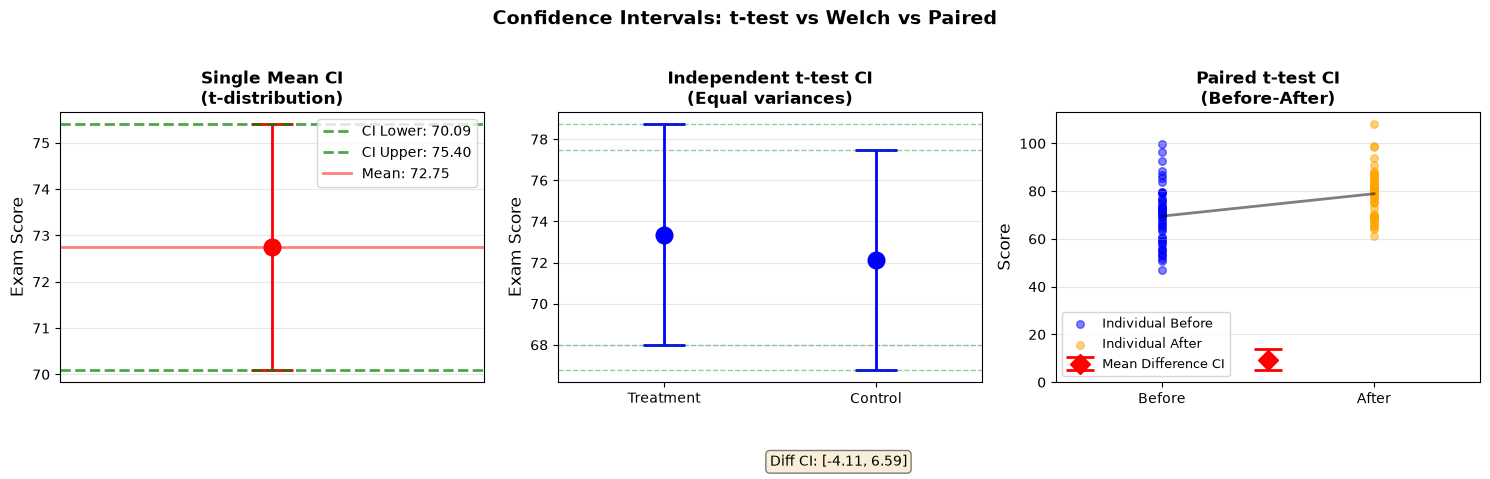

Visualization created!


In [10]:
# Visualize all three CIs

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot 1: Single mean CI
ax1 = axes[0]
ax1.errorbar(1, mean, yerr=margin_of_error, fmt='o', markersize=12, capsize=15, 
             capthick=2, color='red', elinewidth=2)
ax1.axhline(y=ci_lower, color='green', linestyle='--', alpha=0.7, linewidth=2, label=f'CI Lower: {ci_lower:.2f}')
ax1.axhline(y=ci_upper, color='green', linestyle='--', alpha=0.7, linewidth=2, label=f'CI Upper: {ci_upper:.2f}')
ax1.axhline(y=mean, color='red', linestyle='-', alpha=0.5, linewidth=2, label=f'Mean: {mean:.2f}')
ax1.set_xlim(0.5, 1.5)
ax1.set_xticks([])
ax1.set_ylabel('Exam Score', fontsize=12)
ax1.set_title('Single Mean CI\n(t-distribution)', fontsize=12, fontweight='bold')
ax1.legend(loc='upper right', fontsize=10)
ax1.grid(True, alpha=0.3)

# Plot 2: Independent samples (equal var)
ax2 = axes[1]
groups = ['Treatment', 'Control']
means = [mean1, mean2]
ax2.errorbar([1, 2], means, yerr=[me_diff, me_diff], fmt='o', markersize=12, capsize=15,
             capthick=2, color='blue', elinewidth=2)
ax2.axhline(y=mean1 - me_diff, color='green', linestyle='--', alpha=0.4, linewidth=1)
ax2.axhline(y=mean1 + me_diff, color='green', linestyle='--', alpha=0.4, linewidth=1)
ax2.axhline(y=mean2 - me_diff, color='green', linestyle='--', alpha=0.4, linewidth=1)
ax2.axhline(y=mean2 + me_diff, color='green', linestyle='--', alpha=0.4, linewidth=1)
ax2.set_xlim(0.5, 2.5)
ax2.set_xticks([1, 2])
ax2.set_xticklabels(groups)
ax2.set_ylabel('Exam Score', fontsize=12)
ax2.set_title(f'Independent t-test CI\n(Equal variances)', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')
ax2.text(1.5, min(means) - 10, f'Diff CI: [{ci_diff_lower:.2f}, {ci_diff_upper:.2f}]', 
         fontsize=10, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Plot 3: Paired samples
ax3 = axes[2]
positions = [1, 2]
values = [before.mean(), after.mean()]
ax3.scatter([1]*len(before), before, alpha=0.5, s=30, color='blue', label='Individual Before')
ax3.scatter([2]*len(after), after, alpha=0.5, s=30, color='orange', label='Individual After')
ax3.plot([1, 2], values, 'k-', linewidth=2, alpha=0.5)
ax3.errorbar(1.5, mean_diff_paired, yerr=me_paired, fmt='D', markersize=10, capsize=10,
             capthick=2, color='red', elinewidth=2, label='Mean Difference CI')
ax3.set_xlim(0.5, 2.5)
ax3.set_xticks([1, 2])
ax3.set_xticklabels(['Before', 'After'])
ax3.set_ylabel('Score', fontsize=12)
ax3.set_title('Paired t-test CI\n(Before-After)', fontsize=12, fontweight='bold')
ax3.legend(loc='best', fontsize=9)
ax3.grid(True, alpha=0.3, axis='y')

plt.suptitle('Confidence Intervals: t-test vs Welch vs Paired', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("Visualization created!")

## 11. Summary Table

In [11]:
# Create comprehensive summary

print("\n" + "="*90)
print("SUMMARY: CI CALCULATIONS FOR ALL THREE SCENARIOS")
print("="*90)

summary = pd.DataFrame({
    'Scenario': [
        'Single Mean',
        'Difference (Equal Var)',
        'Difference (Unequal Var)',
        'Paired Difference'
    ],
    'Test Used': [
        't-test (df=n-1)',
        't-test (df=n₁+n₂-2)',
        'Welch t-test (Welch df)',
        't-test (df=n-1)'
    ],
    'Point Estimate': [
        f'{mean:.4f}',
        f'{mean_diff:.4f}',
        f'{mean_diff:.4f}',
        f'{mean_diff_paired:.4f}'
    ],
    'CI Lower': [
        f'{ci_lower:.4f}',
        f'{ci_diff_lower:.4f}',
        f'{ci_diff_welch_lower:.4f}',
        f'{ci_paired_lower:.4f}'
    ],
    'CI Upper': [
        f'{ci_upper:.4f}',
        f'{ci_diff_upper:.4f}',
        f'{ci_diff_welch_upper:.4f}',
        f'{ci_paired_upper:.4f}'
    ],
    'p-value': [
        'N/A (single sample)',
        f'{p_value:.4f}',
        f'{p_value_welch:.4f}',
        f'{p_value_paired:.4f}'
    ]
})

print("\n" + summary.to_string(index=False))
print("\n" + "="*90)


SUMMARY: CI CALCULATIONS FOR ALL THREE SCENARIOS

                Scenario               Test Used Point Estimate CI Lower CI Upper             p-value
             Single Mean         t-test (df=n-1)        72.7453  70.0918  75.3987 N/A (single sample)
  Difference (Equal Var)     t-test (df=n₁+n₂-2)         1.2393  -4.1134   6.5920              0.6437
Difference (Unequal Var) Welch t-test (Welch df)         1.2393  -4.1135   6.5921              0.6437
       Paired Difference         t-test (df=n-1)         9.3943   5.0643  13.7244              0.0001



## 12. Decision Tree: When to Use Which Test

In [12]:
print("""
╔════════════════════════════════════════════════════════════════════════════════╗
║                   DECISION TREE: WHICH TEST TO USE?                             ║
╚════════════════════════════════════════════════════════════════════════════════╝

┌─ Do you have ONE sample?
│  └─ YES → Calculate CI for single MEAN using t-test
│           Formula: mean ± (t_critical × SE)
│           Assumption: Data approximately normal OR n > 30
│
└─ Do you have TWO samples?
   │
   ├─ Are measurements on SAME subjects (Before-After, Paired)?
   │  └─ YES → Use PAIRED t-test
   │           - Tests mean of DIFFERENCES
   │           - Df = n - 1 (where n = number of pairs)
   │           - Less affected by individual differences
   │
   └─ Are measurements on DIFFERENT subjects (Independent)?
      └─ YES → Check EQUALITY OF VARIANCES (Levene's test)
            │  p-value > 0.05?
            │
            ├─ YES (Variances are EQUAL)
            │  └─ Use STANDARD t-test
            │      SE = Sp√(1/n₁ + 1/n₂)  [pooled std dev]
            │      Df = n₁ + n₂ - 2
            │      Assumption: Both populations normal + equal variances
            │
            └─ NO (Variances are UNEQUAL)
               └─ Use WELCH'S t-test ✓ RECOMMENDED
                   SE = √(s₁²/n₁ + s₂²/n₂)  [no pooling]
                   Df = Welch-Satterthwaite formula
                   Assumption: Both populations normal (variances can differ)
                   → More robust, recommended by most statisticians

╔════════════════════════════════════════════════════════════════════════════════╗
║                          KEY FORMULAS SUMMARY                                   ║
╚════════════════════════════════════════════════════════════════════════════════╝

1. SINGLE MEAN CI:
   CI = x̄ ± t(df, α/2) × SE
   where SE = s/√n, df = n - 1

2. INDEPENDENT t-TEST (Equal Variances):
   SE_diff = Sp√(1/n₁ + 1/n₂)
   Sp = √[((n₁-1)s₁² + (n₂-1)s₂²)/(n₁+n₂-2)]
   df = n₁ + n₂ - 2

3. WELCH'S t-TEST (Unequal Variances):
   SE_diff = √(s₁²/n₁ + s₂²/n₂)  [unpooled]
   df = [SE_diff²]² / [(s₁²/n₁)²/(n₁-1) + (s₂²/n₂)²/(n₂-1)]
   (Welch-Satterthwaite df - usually non-integer)

4. PAIRED t-TEST:
   CI for mean difference = d̄ ± t(n-1, α/2) × (sd/√n)
   where d = differences, sd = std of differences

╔════════════════════════════════════════════════════════════════════════════════╗
║                        INTERPRETATION GUIDELINES                               ║
╚════════════════════════════════════════════════════════════════════════════════╝

• If CI includes 0 → NO significant difference (p > 0.05)
• If CI does NOT include 0 → Significant difference (p < 0.05)
• Wider CI = Less precise estimate (more uncertainty)
• Narrower CI = More precise estimate (less uncertainty)
• Confidence level 95% is standard in most fields
""")


╔════════════════════════════════════════════════════════════════════════════════╗
║                   DECISION TREE: WHICH TEST TO USE?                             ║
╚════════════════════════════════════════════════════════════════════════════════╝

┌─ Do you have ONE sample?
│  └─ YES → Calculate CI for single MEAN using t-test
│           Formula: mean ± (t_critical × SE)
│           Assumption: Data approximately normal OR n > 30
│
└─ Do you have TWO samples?
   │
   ├─ Are measurements on SAME subjects (Before-After, Paired)?
   │  └─ YES → Use PAIRED t-test
   │           - Tests mean of DIFFERENCES
   │           - Df = n - 1 (where n = number of pairs)
   │           - Less affected by individual differences
   │
   └─ Are measurements on DIFFERENT subjects (Independent)?
      └─ YES → Check EQUALITY OF VARIANCES (Levene's test)
            │  p-value > 0.05?
            │
            ├─ YES (Variances are EQUAL)
            │  └─ Use STANDARD t-test
            │      SE = S

## 13. Practice Problem

In [13]:
print("""
╔════════════════════════════════════════════════════════════════════════════════╗
║                              PRACTICE PROBLEM                                   ║
╚════════════════════════════════════════════════════════════════════════════════╝

A researcher wants to compare two teaching methods (A and B) on student performance.

Data:
  Method A: [85, 88, 90, 82, 89, 86, 84, 91, 87, 85]
  Method B: [78, 80, 82, 79, 83, 81, 80, 84, 77, 82]

Tasks:
1. Calculate 95% CI for mean of Method A (single mean)
2. Check if variances are equal using Levene's test
3. Calculate CI for difference using appropriate test (t-test or Welch's)
4. Interpret the results
""")

# Create practice data
method_a = np.array([85, 88, 90, 82, 89, 86, 84, 91, 87, 85])
method_b = np.array([78, 80, 82, 79, 83, 81, 80, 84, 77, 82])

print("\n--- SOLUTION ---\n")

# 1. Single mean CI for Method A
n_a = len(method_a)
mean_a = method_a.mean()
std_a = method_a.std(ddof=1)
se_a = std_a / np.sqrt(n_a)
t_crit_a = stats.t.ppf(0.975, df=n_a-1)
me_a = t_crit_a * se_a
ci_a_lower = mean_a - me_a
ci_a_upper = mean_a + me_a

print(f"1. METHOD A - Single Mean CI (95%):")
print(f"   Mean: {mean_a:.4f}")
print(f"   Std Dev: {std_a:.4f}")
print(f"   CI: [{ci_a_lower:.4f}, {ci_a_upper:.4f}]")

# 2. Levene's test
levene_stat_prac, levene_p_prac = stats.levene(method_a, method_b)
print(f"\n2. LEVENE'S TEST (Equality of Variances):")
print(f"   Test Statistic: {levene_stat_prac:.4f}")
print(f"   p-value: {levene_p_prac:.4f}")
if levene_p_prac > 0.05:
    print(f"   ✓ Variances are EQUAL (p > 0.05) → Use standard t-test")
    use_welch_prac = False
else:
    print(f"   ✗ Variances are UNEQUAL (p < 0.05) → Use Welch's t-test")
    use_welch_prac = True

# 3. CI for difference
t_stat_prac, p_value_prac = ttest_ind(method_a, method_b, equal_var=not use_welch_prac)

mean_b = method_b.mean()
std_b = method_b.std(ddof=1)
mean_diff_prac = mean_a - mean_b

if not use_welch_prac:
    # Standard t-test
    sp_prac = np.sqrt(((n_a-1)*std_a**2 + (len(method_b)-1)*std_b**2) / (n_a + len(method_b) - 2))
    se_diff_prac = sp_prac * np.sqrt(1/n_a + 1/len(method_b))
    df_prac = n_a + len(method_b) - 2
    test_name = "Standard t-test"
else:
    # Welch's t-test
    se_diff_prac = np.sqrt(std_a**2/n_a + std_b**2/len(method_b))
    numerator_prac = (std_a**2/n_a + std_b**2/len(method_b))**2
    denominator_prac = (std_a**2/n_a)**2/(n_a-1) + (std_b**2/len(method_b))**2/(len(method_b)-1)
    df_prac = numerator_prac / denominator_prac
    test_name = "Welch's t-test"

t_crit_prac = stats.t.ppf(0.975, df=df_prac)
me_diff_prac = t_crit_prac * se_diff_prac
ci_diff_prac_lower = mean_diff_prac - me_diff_prac
ci_diff_prac_upper = mean_diff_prac + me_diff_prac

print(f"\n3. DIFFERENCE IN MEANS CI (95%) - Using {test_name}:")
print(f"   Method A mean: {mean_a:.4f}")
print(f"   Method B mean: {mean_b:.4f}")
print(f"   Difference: {mean_diff_prac:.4f}")
print(f"   Standard Error: {se_diff_prac:.4f}")
print(f"   CI: [{ci_diff_prac_lower:.4f}, {ci_diff_prac_upper:.4f}]")
print(f"   t-statistic: {t_stat_prac:.4f}")
print(f"   p-value: {p_value_prac:.4f}")

print(f"\n4. INTERPRETATION:")
if ci_diff_prac_lower > 0:
    print(f"   ✓ Method A is significantly BETTER than Method B")
    print(f"   ✓ The CI does NOT include 0 (p = {p_value_prac:.4f} < 0.05)")
elif ci_diff_prac_upper < 0:
    print(f"   ✓ Method B is significantly BETTER than Method A")
    print(f"   ✓ The CI does NOT include 0 (p = {p_value_prac:.4f} < 0.05)")
else:
    print(f"   ✗ No significant difference between methods")
    print(f"   ✗ The CI includes 0 (p = {p_value_prac:.4f} > 0.05)")


╔════════════════════════════════════════════════════════════════════════════════╗
║                              PRACTICE PROBLEM                                   ║
╚════════════════════════════════════════════════════════════════════════════════╝

A researcher wants to compare two teaching methods (A and B) on student performance.

Data:
  Method A: [85, 88, 90, 82, 89, 86, 84, 91, 87, 85]
  Method B: [78, 80, 82, 79, 83, 81, 80, 84, 77, 82]

Tasks:
1. Calculate 95% CI for mean of Method A (single mean)
2. Check if variances are equal using Levene's test
3. Calculate CI for difference using appropriate test (t-test or Welch's)
4. Interpret the results


--- SOLUTION ---

1. METHOD A - Single Mean CI (95%):
   Mean: 86.7000
   Std Dev: 2.8304
   CI: [84.6753, 88.7247]

2. LEVENE'S TEST (Equality of Variances):
   Test Statistic: 0.7098
   p-value: 0.4106
   ✓ Variances are EQUAL (p > 0.05) → Use standard t-test

3. DIFFERENCE IN MEANS CI (95%) - Using Standard t-test:
   Method A me